In [1]:
import sys
sys.path.append('/Users/danielmartelliti/Documents/dany/projects/TruckCountingRoi')

In [2]:
from core.utils.tracking_detector import TrackingDetector
from core.utils.track_manager import TrackManager
from core.utils.line_2d import Line2D
from application.video_source import VideoSource
from core.dtos.event_dto import EventDto
from core.constants import FlowDirectionCode
from core.utils.flow_event_detector import FlowEventDetector
import time


In [9]:
source = VideoSource("../data/vehicle-counting.mp4")
cap = source.open()

tracking_detector = TrackingDetector(model_name="yolov8n.pt")
track_manager = TrackManager()
flow_event_detector = FlowEventDetector(window=10)
frame_id = 0
events = []

t0 = time.perf_counter()
while True:
    ret, frame = cap.read()
    if not ret:
        break
        
    detections = tracking_detector.process(frame, frame_id=frame_id)
    track_history = track_manager.add(detections)
    events += flow_event_detector.detect(track_history)
    
    frame_id += 1

dt = time.perf_counter() - t0
print(f"Frame {frame_id} → {dt*1000:.2f} ms")

[TrackingDetector] CUDA NOT available — falling back to CPU
Frame 538 → 48733.98 ms


In [10]:
events

[EventDto(id=0, detections=[DetectionDto(bbox=BBoxDto(x1=1315.031494140625, y1=1440.935546875, x2=1609.1331787109375, y2=1688.548828125, img_shape=(2160, 3840)), class_id=2, label='car', confidence=0.7590513229370117, track_id=3, frame_id=33, model_version='models/yolov8n.pt'), DetectionDto(bbox=BBoxDto(x1=1305.01806640625, y1=1460.802490234375, x2=1605.8797607421875, y2=1714.44580078125, img_shape=(2160, 3840)), class_id=2, label='car', confidence=0.8332646489143372, track_id=3, frame_id=34, model_version='models/yolov8n.pt'), DetectionDto(bbox=BBoxDto(x1=1291.2322998046875, y1=1479.3018798828125, x2=1603.8145751953125, y2=1743.181884765625, img_shape=(2160, 3840)), class_id=2, label='car', confidence=0.7147974371910095, track_id=3, frame_id=35, model_version='models/yolov8n.pt'), DetectionDto(bbox=BBoxDto(x1=1288.1241455078125, y1=1497.8563232421875, x2=1602.7716064453125, y2=1764.911865234375, img_shape=(2160, 3840)), class_id=2, label='car', confidence=0.7914682626724243, track_id=

In [4]:
line_2d = Line2D(p1=(500, 1400), p2=(3500, 1400))

In [6]:
for i, track in track_history.tracks.items():
    for det in track.detections:
        status = line_2d.half_plane(det.bbox.center_cartesian)
        print(det.frame_id, i, det.track_id, status, det.bbox.center_cartesian)
    print("--------")

0 1 1 -1 (3080.95458984375, 775.0126342773438)
1 1 1 -1 (3070.897705078125, 785.44287109375)
2 1 1 -1 (3046.543212890625, 797.7481689453125)
3 1 1 -1 (3026.7012939453125, 809.328857421875)
4 1 1 -1 (3002.662841796875, 823.1580200195312)
5 1 1 -1 (2986.158447265625, 834.77783203125)
6 1 1 -1 (2966.1602783203125, 848.3707275390625)
7 1 1 -1 (2948.27587890625, 857.8818969726562)
8 1 1 -1 (2932.8760986328125, 869.9190673828125)
9 1 1 -1 (2912.976806640625, 882.9168090820312)
10 1 1 -1 (2897.7030029296875, 893.4566040039062)
11 1 1 -1 (2881.656005859375, 903.8237915039062)
12 1 1 -1 (2865.924072265625, 913.2045288085938)
13 1 1 -1 (2853.496826171875, 923.2009887695312)
14 1 1 -1 (2835.0081787109375, 932.0886840820312)
15 1 1 -1 (2820.0257568359375, 940.6572265625)
16 1 1 -1 (2806.7197265625, 951.4874267578125)
17 1 1 -1 (2793.669189453125, 960.9058837890625)
18 1 1 -1 (2778.1162109375, 968.0706176757812)
19 1 1 -1 (2765.9173583984375, 975.4237670898438)
20 1 1 -1 (2751.9342041015625, 985.62

In [11]:
events: list[EventDto] = []
event_id = 0
WINDOW = 3

for track_id, track in track_history.tracks.items():

    detections_sorted = sorted(track.detections, key=lambda d: d.frame_id)

    prev_status = None

    for i, det in enumerate(detections_sorted):

        status = line_2d.half_plane(det.bbox.center_cartesian)

        if status == 0:
            continue

        if prev_status is not None and status != prev_status:

            if prev_status == -1 and status == 1:
                direction = FlowDirectionCode.ENTRY

            elif prev_status == 1 and status == -1:
                direction = FlowDirectionCode.EXIT

            else:
                direction = None

            if direction is not None:

                # ---- ventana contextual ----
                start = max(0, i - WINDOW)
                end = min(len(detections_sorted), i + WINDOW + 1)

                context_detections = detections_sorted[start:end]

                event = EventDto(
                    id=event_id,
                    detections=context_detections,
                    event_frame=det.frame_id,
                    status=direction,
                )

                events.append(event)
                event_id += 1

        prev_status = status


ENTER: 2
EXIT : 7


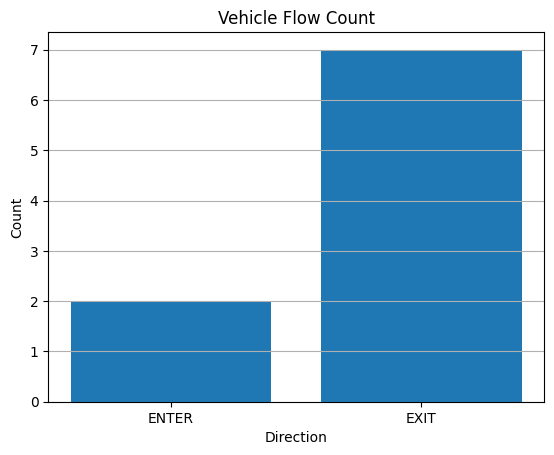

In [11]:
from collections import Counter

counter = Counter(event.status for event in events)

enter_count = counter.get(FlowDirectionCode.ENTRY, 0)
exit_count = counter.get(FlowDirectionCode.EXIT, 0)

print("ENTER:", enter_count)
print("EXIT :", exit_count)


import matplotlib.pyplot as plt

labels = ["ENTER", "EXIT"]
values = [enter_count, exit_count]

plt.figure()
plt.bar(labels, values)

plt.title("Vehicle Flow Count")
plt.xlabel("Direction")
plt.ylabel("Count")

plt.grid(axis="y")
plt.show()


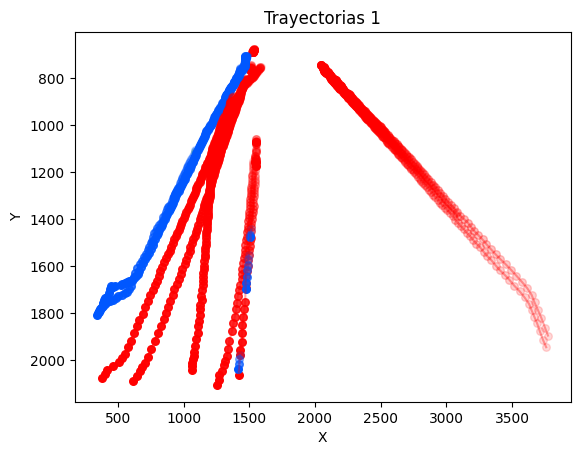

In [7]:
plotter = TrajectoryPlotter()
plotter.plot(df_detections)

In [32]:
tracker_ids = list(set(df_detections.tracker_id))

In [8]:
track_manager.get_tracks()[0]

TrackDto(id=1, detections=[DetectionDto(cx=3080.95458984375, cy=1384.9873046875, class_id=2, confidence=0.8517349362373352, frame_id=0, model_version=None), DetectionDto(cx=3070.897705078125, cy=1374.55712890625, class_id=2, confidence=0.8354941010475159, frame_id=1, model_version=None), DetectionDto(cx=3046.543212890625, cy=1362.2518310546875, class_id=2, confidence=0.7313337326049805, frame_id=2, model_version=None), DetectionDto(cx=3026.701171875, cy=1350.671142578125, class_id=2, confidence=0.859070360660553, frame_id=3, model_version=None), DetectionDto(cx=3002.662841796875, cy=1336.842041015625, class_id=2, confidence=0.7438163757324219, frame_id=4, model_version=None), DetectionDto(cx=2986.158447265625, cy=1325.22216796875, class_id=2, confidence=0.8074671030044556, frame_id=5, model_version=None), DetectionDto(cx=2966.16015625, cy=1311.6292724609375, class_id=2, confidence=0.7540537118911743, frame_id=6, model_version=None), DetectionDto(cx=2948.27587890625, cy=1302.1181640625,

In [7]:
frame.shape[:2]

(2160, 3840)